In [ ]:
%%html
<style>
h1,h2,h3 {
    text-align: center;
}

.term {
    text-align: center;
    margin-top: 1em;
    margin-bottom: 1em;
}

.organizers {
    text-align: center;
    margin-left: 20%;
    margin-right: 20%;
    margin-bottom: 1em;
}

.presenter {
    text-decoration: underline;
}
</style>


# Python Programming for Machine Learning (Machine Learning Engineering)

<div class="term">Summer Term 2026</div>
<br>
<div class="organizers">
    <div>Jannik Wolff</div>
    <div>Stefaan Hessmann</div>
    <div>Max Eißler</div>
    <div>Johannes Maeß</div>
    <div>Frederik Stalschus</div>
    <div>Ryan "Wilbur" Gelston</div>
    <div class="presenter">Julia Henkel</div>
</div>

<center><img src='images/python-logo-only.svg' width=250> </center>

#### Learning Goals
1. Foundations:
Understand python concepts and how they are embedded in ML frameworks (e.g. tensors, vectorization, and computational abstractions)
2. Application level: 
Understand ML workflow and architechtures (high level) to build new ML applications 
3. Systems level:
Learn how to build custom systems beyond standard framework capabilities (e.g. GPU programming, autograd)

#### Course Structure
See ISIS [Lecture Overview](https://isis.tu-berlin.de/mod/page/view.php?id=2253338) and [Tutorial Overview](https://isis.tu-berlin.de/mod/page/view.php?id=2253337).

#### Prerequisites
- Basic Programming Skills (see Tutorial Self-Assessment)
- Math Basics

# Lecture 1: Python in the Context of Programming Languages + Core Concepts

## What is Python and Why is it so Popular?

- [pypl.github.io](https://pypl.github.io/) calculates a programming language popularity index based on Google searches
- since 2019 Python is the most popular language
- de facto it is **the** programming language for Data Science and Machine Learning

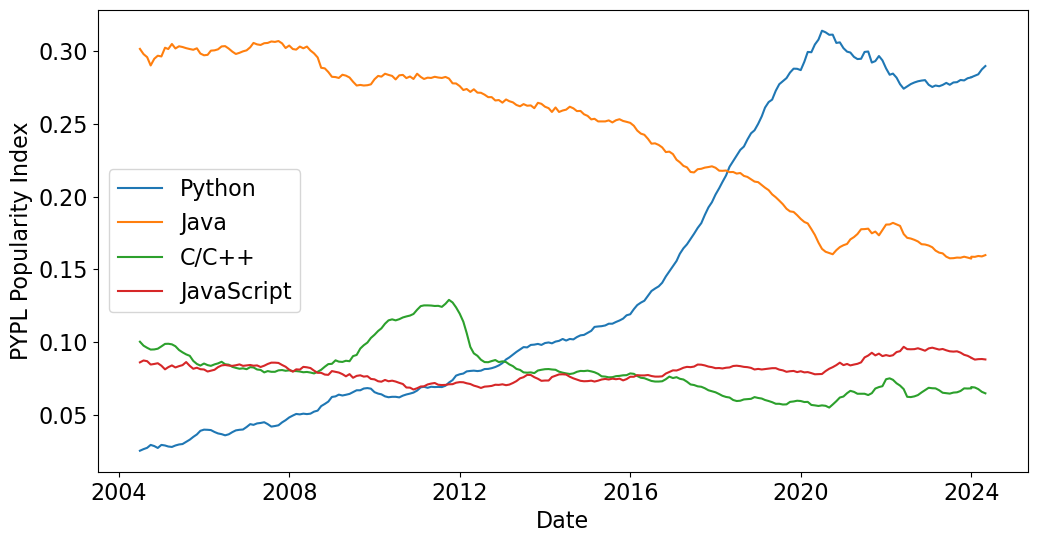

In [1]:
import pandas as pd
import matplotlib.pyplot as p

url = ("https://gist.githubusercontent.com/emiddell/7dea88e36a739f070cb020877b4e3be6"
       "/raw/0bfd1477d649ac0d79ec9ae1a8a942a2cc9070c8/pypl.csv")

data = pd.read_csv(url, parse_dates=["Date"])

p.figure(figsize=(12,6))
p.rc("font", size=16)

for language in ["Python", "Java", "C/C++", "JavaScript"]:
    p.plot(data["Date"], data[language], label=language)

p.legend()
p.xlabel("Date")
p.ylabel("PYPL Popularity Index");

Python is a  **High Level** Language, designed for 
#### Readability & Simplicity
- designed to be easy to read and write
- clean, almost English like syntax
- formating via indentation levels

In [2]:
name = "Alice"
scores = [10, 20, 30]

def average(values):
    return sum(values) / len(values)

avg = average(scores)

if avg > 15:
    print(f"{name} passed with {avg}")

Alice passed with 20.0


Equivalent C-Code: 

<pre>
#include <stdio.h>

double average(int values[], int length) {
    int sum = 0;
    for (int i = 0; i < length; i++) {
        sum += values[i];
    }
    return (double)sum / length;
}

int main() {
    char name[] = "Alice";
    int scores[] = {10, 20, 30};
    int length = 3;

    double avg = average(scores, length);

    if (avg > 15) {
        printf("%s passed with %.2f\n", name, avg);
    }

    return 0;
}
</pre>

#### Expressiveness
- you can express complex code with few lines
- more "conceptual" description of the problem / solution

In [3]:
[x**2 for x in range(10) if x % 2 == 0]

[0, 4, 16, 36, 64]

Equivalent C-Code: 

<pre>
#include <stdio.h>

int main() {
    int result[5];
    int count = 0;

    for (int x = 0; x < 10; x++) {
        if (x % 2 == 0) {
            result[count++] = x * x;
        }
    }

    // Print results
    for (int i = 0; i < count; i++) {
        printf("%d ", result[i]);
    }
    printf("\n");

    return 0;
}
</pre>

#### Interpreted Language & Dynamic typing
Python is an **interpreted** language 

- Compiled languages: (C/C++/Julia) 
    - first translate source code into machine code (executable) then run the executable

- Interpreted language (Python):
    - code is executed *"line-by-line"* by an interpreter
    - you can pause execution, change code or inspect variables



Python interpreter: 
- CPython (default)
    - is a *compiled* c-programm (executable)
- Pypy (JIT compiler)
    - identifies frequently used code block and compiles them to machine code while running (JIT)



<center><img src='images/intepreter.png' width=400> </center>

Python uses Dynamic Typing (variable types are determined at runtime)
- easier to write generic code
- more runtime errors

In [4]:
a = "Alice" 
print(type(a))
a = 10
print(type(a))

<class 'str'>
<class 'int'>


No dynamic typing in C
<pre>
#include <stdio.h>

int main() {
    int count = 0;
    float count = 0.1; //crash!!
    return 0;
}
</pre>

Python uses Automatic Memory Management
- keep track of references to objects
- free memory when object is no longer referenced

Python is slow if not used correctly.

In [5]:
# Slow
c = 0
for i in range(10000000):
    c += i
c

49999995000000

Much faster in C
<pre>
#include <stdio.h>

int main() {
    long long c = 0;

    for (int i = 0; i < 10000000; i++) {
        c += i;
    }

    printf("%lld\n", c);
    return 0;
}
</pre>

In [6]:
# Use libraries / build-in functions!!
sum(range(10000000))

49999995000000

#### [Python Standard Library](https://docs.python.org/3/library/index.html)
- "batteries included" philosophy => installing python comes with a wide range to implemented methods
- file handling, networking, data formats, [...]

In [7]:
from pathlib import Path

for file in Path(".").rglob("*.txt"):
    print(file)

data.txt


#### Portability
- typically Python code can run without modifications on different operating systems (interpreter designed for different systems)
- in contrast compiled c-program is tied to a specific operating system

#### Package Ecosystem / Community
- packages for web-development, scientific computing, machine learning
- manage packages easily with pip/conda

Examples
- [numpy](https://numpy.org/)
    - efficient n-dimensional arrays on the CPU
- [matplotlib](https://matplotlib.org/)
    - plotting 
- [pytorch](https://pytorch.org/)
    - n-dimensional arrays on the CPU & GPU, Autograd, neural nets
- [pandas](https://pandas.pydata.org)
    - data analysis on tabular data
- [scikit-learn](https://scikit-learn.org/)
    - machine learning in Python
- [SciPy](https://scipy.org/)
    - fundamental algorithms for scientific computing in Python
- Cython 
    - integrate c-code into python programms for high performance 

#### Summary 
- high-level language designed for readibility and expressiveness
- interpreted language, dynamic typing, automated memory management
- large standard library
- portability 
- package ecosystem + large community

## Basic Concepts


### Objects, Names and References
- all data in python is represented by **objects** (even numeric types like int / float)
- every object has a **value**, a **type** and an **identity**
- variables are names that point to objects (like pointers in C/C++)
- multiple names can point to the same object

<center><img src='images/name_binding.svg' width=400> </center>

In [8]:
# Namespace: { name=x -> { value=Alice, type=str, id=5084449072 } }

x = "Alice"
print('x', id(x))       # uniquely identifies the object
print('x', type(x))
print()

x 5073173408
x <class 'str'>



In [9]:
z = x
print('z', id(z))
print('z', type(z))
print()

print(id(x)==id(z))

print()

z 5073173408
z <class 'str'>

True



In [10]:
y = "Marie"
print('y', id(y))
print('y', type(y))

y 5073424752
y <class 'str'>


### Mutability
- Mutable types (e.g. list, dict, set)
    - cannot be modified after creation => make a copy

- Immutable types (e.g numeric, bool, string, tuple)
    - can be modified in place


In [11]:
# Numeric (Immutable)
x = 1; y = x
print(x, id(x),'\t', y, id(y))
x += 1

print(x, id(x),'\t', y, id(y))

1 4535580632 	 1 4535580632
2 4535580664 	 1 4535580632


In [12]:
# List (Mutable)
x = [1,2,3,4]; y = x
print(x, id(x),'\t', y, id(y))
x += [5]
print(x, id(x), '\t', y, id(y))

[1, 2, 3, 4] 5074172992 	 [1, 2, 3, 4] 5074172992
[1, 2, 3, 4, 5] 5074172992 	 [1, 2, 3, 4, 5] 5074172992


Take care when using Mutable/Immutable objects as function intput.

In [13]:
def func(num, mylist):
    num = num + 5
    mylist += [':)']

alphabet = ['a','b','c']
x = 0

print(x, alphabet)

0 ['a', 'b', 'c']


In [15]:
func(x, alphabet)
print(x, alphabet)

0 ['a', 'b', 'c', ':)']


### Functions

Functions are objects in python. You can (a.o.): 
- pass function as argument
- add default arguments 
- return multiple arguments as tuple 
- use nested functions

In [16]:
def my_function(func, a, b, scale=1):      # function as argument, default argument

    def log(message):                               # nested function
        print(f"[scale={scale}] {message}")

    result = func(a, b)
    log(f"Raw result: {result}")

    scaled = result * scale
    log(f"Scaled result: {scaled}")

    return result, scaled                           # multiple returns as tuple

type(my_function)

function

Lambda expressions simplify syntax:

In [17]:
add = lambda x, y: x + y
print(add(2, 3)) 

5


You can add type annotations and docstrings to your function but it is not required by the interpreter. 
- code easier to understand 
- find errors earlier e.g. with automatic type checkers (e.g. Pyright or Mypy) 

In [18]:
from typing import Callable, Tuple, Any

def my_function(
    func: Callable[[Any, Any], Any],
    a: Any,
    b: Any,
    scale: float = 1
) -> Tuple[Any, Any]:
    """
    Apply a binary function to two inputs, log the result, and return both
    the original and a scaled version of the result.

    Args:
        func (Callable[[Any, Any], Any]):
            A function that takes two arguments (a and b) and returns a value.
        a (Any):
            The first argument to pass to `func`.
        b (Any):
            The second argument to pass to `func`.
        scale (float, optional):
            A multiplier applied to the result. Defaults to 1.

    Returns:
        Tuple[Any, Any]:
            A tuple containing:
            - result: The raw output from `func(a, b)`
            - scaled: The result multiplied by `scale`

    Notes:
        - Demonstrates higher-order functions (functions as arguments).
        - Uses a closure (`log`) that captures the `scale` variable.
        - Prints intermediate logging information.
    """

    def log(message: str) -> None:
        """Log a message prefixed with the current scale."""
        print(f"[scale={scale}] {message}")

    result = func(a, b)
    log(f"Raw result: {result}")

    scaled = result * scale
    log(f"Scaled result: {scaled}")

    return result, scaled

### Unpacking / Packing

You can sssign elements of a sequence to multiple variables in one step.

In [19]:
features    = [0.6, 0.4, 0.2]
x1, x2, x3  = features

You can also unpack directly into function calls: 
- `*features`: unpack list into positional arguments
- `**params`: unpack dict into keyword arguments

In [20]:
def predict(x1, x2, x3, bias=0, scale=1):
    pass

features    = [0.6, 0.4, 0.2]
params      = {"bias": 0.1, "scale": 2.0} 

# Without unpacking
x1, x2, x3 = features
predict(x1, x2, x3, bias = params['bias'], scale = params['scale'])

# With unpacking
predict(*features, **params)        # unpacking

Packing: define functions that accept a flexible number of inputs
- `*args`: collect positional arguments into a tuple
- `**kwargs`: collect keyword arguments into a dict

In [21]:
def my_func(*args, **kwargs):
    print("args:", args)
    print("kwargs:", kwargs)
    print()

my_func(1,5,6, bias = 44, sclae = 4)
my_func(1, bias = 44)


args: (1, 5, 6)
kwargs: {'bias': 44, 'sclae': 4}

args: (1,)
kwargs: {'bias': 44}



In [22]:
my_func(*features, **params)

args: (0.6, 0.4, 0.2)
kwargs: {'bias': 0.1, 'scale': 2.0}



Often used in class (inheritence):

In [23]:
class Parent:
    def __init__(self, x):
        self.x = x

class Child(Parent):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)

## Advanced Concepts 

- Dunder methods
- Context Manager
- Iterators / Generators
- Decorators

### Dunder methods
=> short for "double underscore" methods (they start end with underscores)


Class methods that let you define how your object behaves with 
- build-in functions (e.g. `len()`, `str()`)
- operators (e.g. `+`, `*`)
- comparison methods (e.g. `==`, `<`, `>`)

Examples. 
- `__init__`: initialization
- `__str__`: string representation for users
- `__repr__`: string representation for developers
- `__eq__`: equality comparison
- `__lt__`, `__gt__`: ordering comparisons
- `__getitem__`: accessing elements of a sequence
- `__len__`: length of the object

more here: https://www.pythonmorsels.com/every-dunder-method/




In [24]:
class Vector:
    def __init__(self, x, y):
        self.x = x
        self.y = y

    # addition
    def __add__(self, other):
        if not isinstance(other, Vector):
            return NotImplemented
        return Vector(self.x + other.x, self.y + other.y)

    # equality comparison
    def __eq__(self, other):
        if not isinstance(other, Vector):
            return NotImplemented
        return self.x == other.x and self.y == other.y

    # print
    def __repr__(self):
        return f"Vec: [{self.x}, {self.y}]"

In [25]:
v1 = Vector(2, 3)
v2 = Vector(4, 5)

In [26]:
v1, v2       # calls v1.__repr__()

(Vec: [2, 3], Vec: [4, 5])

In [27]:
v3 = v1 + v2  # calls v1.__add__(v2)
v3

Vec: [6, 8]

In [28]:
v1 == v3     # calls v1.__eq__(v3)

False

### Context Manager

Use context manager to deal with resources that need proper setup and cleanup 
- opening files 
- database connections 
- threads

In [29]:
# you could handle file like this
f = open("data.txt", "r")
try:
    data = f.read()
finally:
    f.close()

Context managers simplify syntax using `with` keyword:

In [30]:
with open("data.txt", "r") as f:
    f.read()

You can build your own context manager by implementing dunder methods `__enter__()`and `__exit__()`

In [31]:
class MyContext:
    def __enter__(self):
        print("Entering context")
        return self
    
    def __exit__(self, exc_type, exc_value, traceback):
        print("Exiting context")

In [32]:
with MyContext():
    print("Inside block")

Entering context
Inside block
Exiting context


### Iterators / Generators 

In [33]:
# we can loop over build-in sequence types (e.g. list, tuples)  
s = 0
for a in [10,20,30]:
    s += a

Can we loop over our own types? E.g. in ML

In [35]:
for batch in dataloader: 
    train_step(batch)

for line in file:
    process(line)

for step in environment:
    action = policy(step)

In ML data might be
- too large to fit into memory / required to be loaded on demand
- dynamically generated (e.g. reinforcement learning, simulations)

=> we want to process data one element at a time (not load everything at once).

**Iterators** and **Generators** allow for **lazy evalutation**.

#### Hidden For Loop
- a for loop is internally a while loop using `__iter__()` and `__next__()`


In [36]:
# hidden for loop 
iterator = iter([10,20,30])             # create iterator object
while True:
    try:
        x = next(iterator)              # ask iterator for the next value
        print(x)
    except StopIteration:
        break

10
20
30


#### Iterators
An iterator implements
- `__iter__()` => return the iterator object
- `__next__()` => return next value or raise StopException

In [37]:
# Custom Iterator Example 

class CountUp:
    def __init__(self, max):
        self.current = 0
        self.max = max

    def __iter__(self):
        return self

    def __next__(self):
        if self.current > self.max:
            raise StopIteration
        val = self.current 
        self.current += 1
        return val

In [38]:
counter = CountUp(3)
for i in counter: 
    print(i)

0
1
2
3


In [39]:
it = iter(CountUp(3))       # call .__iter__()
print(next(it))             # call .__next__()
print(next(it))

0
1


#### Generators 
- provide a simpler way to build iterators 
- keyword `yield`: 
    - returns a value and **pauses the function**
    - exectuion resumes with the next `__next__()` call

In [40]:
def count_up(max):  # generator function
    i = 0
    while i <= max:
        yield i     # pauses the function and return the value, continue here after __next__()
        i+= 2    

In [41]:
counter = count_up(3)
print('--')
for i in counter: 
    print(i)

--
0
2


#### Example: Lazy File Loading

In [42]:
def read_lines(path):
    with open(path, "r") as file:
        for line in file:
            yield line.strip()

In [44]:
for line in read_lines("data.txt"):
    # training 
    print(line)

id,name,age,score,city
1,Alice,25,88.5,Berlin
2,Bob,thirty,72.0,Hamburg
3,Charlie,35,,Munich
4,David,28,91.2,
5,Eve,22,85.0,Berlin


#### Example: Dataloader

In [45]:
class DataLoader:
    def __init__(self, data, batch_size):
        self.data = data
        self.batch_size = batch_size

    def __iter__(self):
        self.index = 0  # reset every new iteration
        return self

    def __next__(self):
        if self.index >= len(self.data):
            raise StopIteration
        
        batch = self.data[self.index:self.index + self.batch_size]
        self.index += self.batch_size
        return batch

In [46]:
data = [1, 2, 3, 4, 5, 6, 7]
loader = DataLoader(data, batch_size=3)

for batch in loader:
    print(batch)

[1, 2, 3]
[4, 5, 6]
[7]


#### Generator expression

In [47]:
gen = (x * x for x in range(50000))        # gen is an iterator, computed (lazily) when called

In [48]:
for i in gen:
    print(i)
    if i > 3:
        break

0
1
4


Generator sxpressions are different from list comprehension

In [49]:
# List comprehension
lst = [x * x for x in range(50000)]        # lst is a list with all values x**2

import sys
print("List:", sys.getsizeof(lst))
print("Generator:", sys.getsizeof(gen))

List: 444376
Generator: 200


### Decorators
- decorators are functions that wrap and modify the behavior of other functions (or classes)
- they can be applied with the `@` syntax
  

In [68]:
@timer
def slow_function():
    pass

under the hood, this is equivalent to 

In [69]:
slow_function = timer(slow_function)

#### Example: Track execution time

In [70]:
import time 

def slow_function():
    time.sleep(1)

Define a decorator that measures execution time.

In [71]:
def timer(func):
    def wrapper():                      # wraps the original function
        start = time.time()
        func()                          # run the original function 
        end = time.time()
        print(f"Execution time: {end - start:.4f} seconds")
    return wrapper

Apply it manually

In [72]:
# update our function to be time tracked
slow_function = timer(slow_function)
slow_function()

Execution time: 1.0002 seconds


Or use decorator syntax

In [73]:
# equivalent decorator notation
@timer
def slow_function():
    time.sleep(1)

#### General decorator pattern

To make the decorator work with any function signature, use `*args` and `**kwargs`

In [74]:
def timer(func):
    def wrapper(*args, **kwargs):   
        start = time.time()
        result = func(*args, **kwargs) 
        end = time.time()
        print(f"Execution time: {end - start:.4f} seconds")
        return result
    return wrapper

@timer
def slow_function(x1, x2 = 3):
    time.sleep(1)

slow_function(1,2)

Execution time: 1.0032 seconds


You can also add arguments to the decorator 

In [75]:
import time
from functools import wraps

def timer(print_result=True, precision=4):
    def decorator(func):
        @wraps(func)
        def wrapper(*args, **kwargs):
            start = time.time()
            result = func(*args, **kwargs)
            end = time.time()

            if print_result:
                print(f"Execution time: {end - start:.{precision}f} seconds")

            return result
        return wrapper
    return decorator

@timer(precision=2)
def slow_function():
    time.sleep(1)

#### Example: Model Register - Class Decorator with Arguments 

Keep a dictionary `MODEL_REGISTRY` to map from model name to model class

In [76]:
class ResNet: 
    pass
class BERTModel:
    pass

# manual registry
MODEL_REGISTRY = {}
MODEL_REGISTRY["resnet"] = ResNet
MODEL_REGISTRY["bert"] = BERTModel

In [77]:
# automatic model instantiation with config file
model = MODEL_REGISTRY[config["model"]]()

NameError: name 'config' is not defined

Use decorators to keep registration and class definition in one place.

In [ ]:
def register_model(name):
    def decorator(cls):     # class as input
        MODEL_REGISTRY[name] = cls
        return cls
    return decorator

In [ ]:
MODEL_REGISTRY = {}

@register_model("resnet")
class ResNet:
    pass

In [ ]:
# equivalent to 
MODEL_REGISTRY = {}
ResNet = register_model('resnet')(ResNet)

Summary Decorators

- Build abstraction that:
  - performs computation before/after a function or code block
  - optionally also adjusts the function behavior/output
- Why abstraction (not: write this out "manually")?
  - Re-usable
  - Improved readability (factor out complexity)
  - Improved testability (test **only** this abstraction)

More relevant examples:
- logging
- input validation
- gradient computation (`@torch.no_grad`)
- device management